<div dir="rtl">

# Phase 1 — Data Understanding

الهدف من الـPhase دي إننا نفهم الـraw dataset كويس قبل ما نبدأ أي Cleaning أو Transformation.

هنبدأ بالتأكد من حجم الداتا والـcolumns الأساسية، وبعدها نفهم الـdata types وجودة البيانات والعلاقات المهمة بينها.

In [15]:
import pandas as pd

# Load the raw dataset
df = pd.read_csv("Order_delivery.csv")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 100,002
Columns: 23


<div dir="rtl">

## Step 1A — Preview & Column Name Consistency

بنراجع أول وآخر rows وrandom sample، ونتأكد إن أسماء الـcolumns موحدة من ناحية:
- leading/trailing spaces
- empty names
- duplicate names
- unexpected special characters
- casing/formatting

الـchecks هنا **inspection فقط** ومش بتعدل الـraw dataset.
</div>

In [16]:
# Preview first, last, and random rows

print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nRandom sample (5 rows):")
display(df.sample(n=min(5, len(df)), random_state=42))


# Column-name consistency checks

column_name_check = pd.DataFrame({
    "Column": df.columns,
    "Has Leading/Trailing Spaces": [
        col != col.strip() for col in df.columns
    ],
    "Has Empty Name": [
        col.strip() == "" for col in df.columns
    ],
    "Has Special Characters": [
        not col.replace("_", "").isalnum() for col in df.columns
    ]
})

duplicate_column_names = df.columns[df.columns.duplicated()].tolist()

print("\nDuplicate column names:", duplicate_column_names)
display(column_name_check)


First 5 rows:


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,16-06-2025 08:32,16-06-2025 09:11,39,...,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,03-06-2025 21:27,03-06-2025 22:00,33,...,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,01-06-2025 14:48,01-06-2025 15:26,38,...,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,13-06-2025 02:30,13-06-2025 03:22,52,...,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,06-06-2025 09:48,06-06-2025 10:32,44,...,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online



Last 5 rows:


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
99997,99998,U2735,12,88,Fried Chicken,4,165.60,02-06-2025 22:51,02-06-2025 23:33,42,...,Bicycle,30.594678,31.489688,30.592766,31.505024,30.587210,31.510486,1.485960,Low,Online
99998,99999,U7356,570,473,Koshary,4,199.84,11-06-2025 06:09,11-06-2025 06:49,40,...,Bicycle,30.786478,31.004323,30.768406,31.013934,30.793099,31.016429,2.204660,Low,Offline
99999,100000,U3960,790,283,Koshary,5,235.30,14-06-2025 23:01,14-06-2025 23:48,47,...,Motorbike,31.033496,31.361562,31.046063,31.381597,31.042967,31.387703,2.366264,Low,Online
100000,100001,U5821,345,172,Burger,2,89.50,15-06-2025 13:25,15-06-2025 14:02,37,...,Motorbike,30.044400,31.235700,30.055200,31.245100,30.050100,31.240300,1.620000,Medium,Online
100001,100002,U9147,621,391,Pizza,3,142.75,15-06-2025 19:40,15-06-2025 20:28,48,...,Car,31.200100,29.918700,31.211400,29.932100,31.205800,29.925400,2.310000,High,Online



Random sample (5 rows):


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
62004,62005,U5208,433,325,Shawarma,3,278.85,16-06-2025 08:41,16-06-2025 09:06,25,...,Motorbike,27.174867,31.179706,27.171302,31.201404,27.173140,31.186869,2.186329,High,Online
58589,58590,U8042,928,289,Sandwich,2,266.56,05-06-2025 22:44,05-06-2025 23:10,26,...,Motorbike,27.183096,31.186007,27.191048,31.184780,27.178496,31.167844,0.889438,Low,Offline
1956,1957,U5918,751,68,Sandwich,2,106.40,02-06-2025 11:08,02-06-2025 11:38,30,...,Bicycle,30.792203,30.997145,30.774994,31.000633,30.790372,31.002167,1.936853,Medium,Online
11529,11530,U8238,831,99,Fried Chicken,5,669.55,11-06-2025 02:47,11-06-2025 03:14,27,...,Car,30.595299,31.516150,30.589625,31.521300,30.590429,31.520299,0.799837,Low,Online
39495,39496,U8762,514,412,Fried Chicken,3,152.88,13-06-2025 04:06,13-06-2025 04:59,53,...,Car,31.189958,29.933776,31.193709,29.924946,31.186613,29.935487,0.938768,Low,Online



Duplicate column names: []


,Column,Has Leading/Trailing Spaces,Has Empty Name,Has Special Characters
0,Order_ID,False,False,False
1,User_ID,False,False,False
2,Restaurant_ID,False,False,False
3,Driver_ID,False,False,False
4,Item_Name,False,False,False
5,Quantity,False,False,False
6,Total_Price,False,False,False
7,Order_Time,False,False,False
8,Delivery_Time,False,False,False
9,Delivery_Duration_Minutes,False,False,False


In [17]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

Column names:
['Order_ID', 'User_ID', 'Restaurant_ID', 'Driver_ID', 'Item_Name', 'Quantity', 'Total_Price', 'Order_Time', 'Delivery_Time', 'Delivery_Duration_Minutes', 'City', 'Payment_Method', 'Order_Status', 'Driver_Vehicle', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'Traffic_Level', 'Driver_Availability']

Data types:


,Data Type
Order_ID,int64
User_ID,str
Restaurant_ID,int64
Driver_ID,int64
Item_Name,str
Quantity,int64
Total_Price,float64
Order_Time,str
Delivery_Time,str
Delivery_Duration_Minutes,int64


<div dir="rtl">

## Step 2 Column Understanding & Data Types

هنا بنبص على كل الـcolumns في الـraw dataset، ونحدد الـcurrent data type اللي Pandas قرأته، وبعدها الـlogical type المناسب للتحليل.

الفكرة إن بعض الأعمدة ممكن تكون مقروءة كـnumeric أو `object`، لكن استخدامها الحقيقي في التحليل مختلف، زي الـIDs والـtimestamps.



In [18]:
import pandas as pd

# Load raw dataset
df = pd.read_csv("Order_delivery.csv")

# Logical types based on the meaning of each column
logical_types = {
    "Order_ID": "Identifier",
    "User_ID": "Identifier",
    "Restaurant_ID": "Identifier",
    "Driver_ID": "Identifier",
    "Item_Name": "Categorical",
    "Quantity": "Discrete numerical",
    "Total_Price": "Continuous numerical",
    "Order_Time": "Datetime",
    "Delivery_Time": "Datetime",
    "Delivery_Duration_Minutes": "Duration / discrete numerical",
    "City": "Categorical / geographic identifier",
    "Payment_Method": "Categorical",
    "Order_Status": "Categorical",
    "Driver_Vehicle": "Categorical",
    "Restaurant_Lat": "Latitude / continuous numerical",
    "Restaurant_Lon": "Longitude / continuous numerical",
    "Customer_Lat": "Latitude / continuous numerical",
    "Customer_Lon": "Longitude / continuous numerical",
    "Driver_Lat": "Latitude / continuous numerical",
    "Driver_Lon": "Longitude / continuous numerical",
    "Delivery_Distance_km": "Continuous numerical",
    "Traffic_Level": "Ordinal categorical",
    "Driver_Availability": "Binary categorical"
}

roles = {
    "Order_ID": "Primary record identifier",
    "User_ID": "Customer/user identifier",
    "Restaurant_ID": "Restaurant identifier",
    "Driver_ID": "Driver identifier",
    "Item_Name": "Ordered item category",
    "Quantity": "Order quantity",
    "Total_Price": "Order monetary amount",
    "Order_Time": "Order timestamp",
    "Delivery_Time": "Delivery timestamp",
    "Delivery_Duration_Minutes": "Delivery duration outcome",
    "City": "Delivery city",
    "Payment_Method": "Payment type",
    "Order_Status": "Order outcome/status",
    "Driver_Vehicle": "Driver vehicle type",
    "Restaurant_Lat": "Restaurant geographic coordinate",
    "Restaurant_Lon": "Restaurant geographic coordinate",
    "Customer_Lat": "Customer geographic coordinate",
    "Customer_Lon": "Customer geographic coordinate",
    "Driver_Lat": "Driver geographic coordinate",
    "Driver_Lon": "Driver geographic coordinate",
    "Delivery_Distance_km": "Delivery distance measure",
    "Traffic_Level": "Traffic condition category",
    "Driver_Availability": "Driver availability status"
}

# Build a compact column-understanding table
column_understanding = pd.DataFrame({
    "Column": df.columns,
    "Current dtype": [df[col].dtype for col in df.columns],
    "Logical type": [logical_types[col] for col in df.columns],
    "Role": [roles[col] for col in df.columns],
    "Unique values": [df[col].nunique(dropna=True) for col in df.columns]
})

column_understanding

,Column,Current dtype,Logical type,Role,Unique values
0,Order_ID,int64,Identifier,Primary record identifier,100002
1,User_ID,str,Identifier,Customer/user identifier,9000
2,Restaurant_ID,int64,Identifier,Restaurant identifier,1000
3,Driver_ID,int64,Identifier,Driver identifier,500
4,Item_Name,str,Categorical,Ordered item category,9
5,Quantity,int64,Discrete numerical,Order quantity,5
6,Total_Price,float64,Continuous numerical,Order monetary amount,35618
7,Order_Time,str,Datetime,Order timestamp,21367
8,Delivery_Time,str,Datetime,Delivery timestamp,21396
9,Delivery_Duration_Minutes,int64,Duration / discrete numerical,Delivery duration outcome,46



<div dir="rtl">

## Step 3 — Missing Values & Duplicates

هنا بنعمل basic Data Quality check على الـraw dataset.

هنشوف:
- هل فيه Missing Values؟
- هل فيه Exact Full-Row Duplicates؟

مهم: تكرار الـUser_ID أو Restaurant_ID أو Driver_ID مش معناه إن الـrow duplicate، لأننا هنا بنفحص الـfull row بالكامل.

<div dir="rtl">

## Step 3A — Disguised Missing Values & Per-Column Decisions

الـmissing values مش دايمًا بتظهر كـ`NaN`. ممكن تظهر كـblank أو `N/A` أو `-` أو `999` وغيرها.

هنا:
1. نكتشف الـplaceholders.
2. نعمل decision table لكل column.
3. **ما نعملش imputation عشوائي** قبل فهم معنى الـmissingness.

الـ`999` يتم flag له فقط في الـnumeric columns، لأن الرقم قد يكون valid في بعض الأعمدة.
</div>

In [19]:
# Detect disguised missing values in text columns

missing_tokens = {
    "", "n/a", "na", "null", "none",
    "unknown", "unk", "-", "--", "?", "missing"
}

disguised_missing = []

for col in df.columns:
    if df[col].dtype == "object":
        normalized = df[col].astype("string").str.strip().str.lower()
        count = normalized.isin(missing_tokens).sum()
    else:
        count = 0

    disguised_missing.append({
        "Column": col,
        "Disguised Missing Tokens": int(count)
    })

disguised_missing = pd.DataFrame(disguised_missing)
display(disguised_missing)


# Flag suspicious numeric placeholders without automatically changing them

numeric_placeholder_check = pd.DataFrame({
    "Column": df.select_dtypes(include="number").columns,
    "999 Count": [
        int((df[col] == 999).sum())
        for col in df.select_dtypes(include="number").columns
    ],
    "-999 Count": [
        int((df[col] == -999).sum())
        for col in df.select_dtypes(include="number").columns
    ]
})

display(numeric_placeholder_check)


,Column,Disguised Missing Tokens
0,Order_ID,0
1,User_ID,0
2,Restaurant_ID,0
3,Driver_ID,0
4,Item_Name,0
5,Quantity,0
6,Total_Price,0
7,Order_Time,0
8,Delivery_Time,0
9,Delivery_Duration_Minutes,0


,Column,999 Count,-999 Count
0,Order_ID,1,0
1,Restaurant_ID,88,0
2,Driver_ID,0,0
3,Quantity,0,0
4,Total_Price,0,0
5,Delivery_Duration_Minutes,0,0
6,Restaurant_Lat,0,0
7,Restaurant_Lon,0,0
8,Customer_Lat,0,0
9,Customer_Lon,0,0


In [20]:
# Per-column missingness decision table
# This is a documented plan; review the reason/action before executing Cleaning.

missing_decisions = []

for col in df.columns:
    missing_count = int(df[col].isna().sum())
    missing_pct = missing_count / len(df) * 100

    if missing_count == 0:
        action = "Keep — no missing values"
        reason = "No missing values detected."
    elif pd.api.types.is_numeric_dtype(df[col]):
        action = "Impute with median OR flag"
        reason = "Median is robust to skew/outliers; confirm business meaning first."
    elif pd.api.types.is_datetime64_any_dtype(df[col]):
        action = "Investigate; do not blindly impute"
        reason = "Datetime imputation can create false event times."
    else:
        action = "Impute with mode OR flag"
        reason = "Mode preserves an existing category; confirm that missingness is not informative."

    missing_decisions.append({
        "Column": col,
        "Missing Count": missing_count,
        "Missing %": round(missing_pct, 4),
        "Proposed Action": action,
        "Reason": reason
    })

missing_decisions = pd.DataFrame(missing_decisions)
display(missing_decisions)


,Column,Missing Count,Missing %,Proposed Action,Reason
0,Order_ID,0,0.0,Keep — no missing values,No missing values detected.
1,User_ID,0,0.0,Keep — no missing values,No missing values detected.
2,Restaurant_ID,0,0.0,Keep — no missing values,No missing values detected.
3,Driver_ID,0,0.0,Keep — no missing values,No missing values detected.
4,Item_Name,0,0.0,Keep — no missing values,No missing values detected.
5,Quantity,0,0.0,Keep — no missing values,No missing values detected.
6,Total_Price,0,0.0,Keep — no missing values,No missing values detected.
7,Order_Time,0,0.0,Keep — no missing values,No missing values detected.
8,Delivery_Time,0,0.0,Keep — no missing values,No missing values detected.
9,Delivery_Duration_Minutes,0,0.0,Keep — no missing values,No missing values detected.


In [21]:
# Missing Values
missing_values = df.isna().sum()

print("Missing Values per Column:")
display(
    missing_values.to_frame("Missing Values")
)

print(f"\nTotal Missing Values: {missing_values.sum()}")


# Exact Full-Row Duplicates
duplicate_count = df.duplicated().sum()
unique_rows = len(df) - duplicate_count

print(f"\nTotal Rows: {len(df):,}")
print(f"Unique Rows: {unique_rows:,}")
print(f"Exact Full-Row Duplicates: {duplicate_count:,}")
print(f"Duplicate Percentage: {duplicate_count / len(df) * 100:.6f}%")

Missing Values per Column:


,Missing Values
Order_ID,0
User_ID,0
Restaurant_ID,0
Driver_ID,0
Item_Name,0
Quantity,0
Total_Price,0
Order_Time,0
Delivery_Time,0
Delivery_Duration_Minutes,0



Total Missing Values: 0

Total Rows: 100,002
Unique Rows: 100,002
Exact Full-Row Duplicates: 0
Duplicate Percentage: 0.000000%


<div dir="rtl">

## Step 4 — Unique Values & Value-Level Inspection

هنا بنبص على الـunique values والـcardinality لكل column، وبعدها نراجع الـcategorical values بشكل أوضح.

الهدف إننا نعرف طبيعة الـcolumns ونكتشف أي inconsistent labels أو placeholder values أو values غير منطقية بشكل واضح، من غير ما نعمل Cleaning في المرحلة دي.

</div>

In [22]:
# Unique values / Cardinality for all columns

cardinality = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique(dropna=True) for col in df.columns],
    "Unique %": [
        round(df[col].nunique(dropna=True) / len(df) * 100, 4)
        for col in df.columns
    ]
})

display(cardinality)

,Column,Unique Values,Unique %
0,Order_ID,100002,100.0000
1,User_ID,9000,8.9998
2,Restaurant_ID,1000,1.0000
3,Driver_ID,500,0.5000
4,Item_Name,9,0.0090
5,Quantity,5,0.0050
6,Total_Price,35618,35.6173
7,Order_Time,21367,21.3666
8,Delivery_Time,21396,21.3956
9,Delivery_Duration_Minutes,46,0.0460


In [23]:
# Inspect the main categorical columns

categorical_columns = [
    "City",
    "Payment_Method",
    "Order_Status",
    "Driver_Vehicle",
    "Traffic_Level",
    "Driver_Availability",
    "Item_Name"
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(f"Unique values: {df[col].nunique(dropna=True)}")
    display(
        df[col]
        .value_counts(dropna=False)
        .rename("Count")
        .to_frame()
    )


--- City ---
Unique values: 7


,Count
City,
Zagazig,14538
Cairo,14382
Tanta,14336
Assiut,14302
Giza,14232
Alexandria,14168
Mansoura,14044



--- Payment_Method ---
Unique values: 3


,Count
Payment_Method,
Cash,33528
Wallet,33251
Credit Card,33223



--- Order_Status ---
Unique values: 3


...

,Count
Traffic_Level,
Low,45826
High,29221
Medium,24955



--- Driver_Availability ---
Unique values: 2


,Count
Driver_Availability,
Online,90113
Offline,9889



--- Item_Name ---
Unique values: 9


,Count
Item_Name,
Shawarma,11320
Pizza,11230
Fried Chicken,11171
Burger,11130
Pasta,11077
Sandwich,11061
Koshary,11033
Sushi,10990
Salad,10990


In [24]:
# Basic consistency checks for string/categorical values

string_columns = df.select_dtypes(include=["object", "string"]).columns

consistency_results = []

for col in string_columns:
    values = df[col].astype("string")

    whitespace_count = (values != values.str.strip()).sum()

    normalized = values.str.strip().str.lower()

    placeholder_values = {
        "", "unknown", "unk", "n/a", "na",
        "null", "none", "-", "--", "?", "0"
    }

    placeholder_count = normalized.isin(placeholder_values).sum()

    consistency_results.append({
        "Column": col,
        "Leading/Trailing Whitespace": int(whitespace_count),
        "Placeholder Values": int(placeholder_count)
    })

consistency_results = pd.DataFrame(consistency_results)

display(consistency_results)

,Column,Leading/Trailing Whitespace,Placeholder Values
0,User_ID,0,0
1,Item_Name,0,0
2,Order_Time,0,0
3,Delivery_Time,0,0
4,City,0,0
5,Payment_Method,0,0
6,Order_Status,0,0
7,Driver_Vehicle,0,0
8,Traffic_Level,0,0
9,Driver_Availability,0,0


<div dir="rtl">

## Step 4A — Allowed Values & Encoding Checks

هنا بنتأكد إن الـcategorical columns تحتوي فقط على القيم المتوقعة، ونفحص النصوص بحثًا عن علامات encoding problems.

الهدف هو **اكتشاف** المشاكل قبل الـCleaning، وليس تعديل القيم في Phase 1.
</div>

In [25]:
# Allowed categorical values

allowed_values = {
    "Payment_Method": {"Cash", "Wallet", "Credit Card"},
    "Order_Status": {"Delivered", "Cancelled", "In Transit"},
    "Driver_Vehicle": {"Bicycle", "Car", "Motorbike"},
    "Traffic_Level": {"Low", "Medium", "High"},
    "Driver_Availability": {"Online", "Offline"}
}

allowed_results = []

for col, allowed in allowed_values.items():
    observed = set(df[col].dropna().astype(str).str.strip().unique())
    unexpected = sorted(observed - allowed)

    allowed_results.append({
        "Column": col,
        "Allowed Values": ", ".join(sorted(allowed)),
        "Observed Unique": len(observed),
        "Unexpected Values": len(unexpected),
        "Unexpected Examples": ", ".join(unexpected[:10])
    })

allowed_results = pd.DataFrame(allowed_results)
display(allowed_results)


# Basic encoding / mojibake screening

suspicious_markers = [
    "�",      # Unicode replacement character
    "Ã",      # Common UTF-8/Latin-1 mojibake
    "Â",      # Common UTF-8/Latin-1 mojibake
    "â€™",    # Curly apostrophe mojibake
    "â€œ",    # Left double quote mojibake
    "â€",     # Other UTF-8 mojibake
]

encoding_results = []

for col in string_columns:
    values = df[col].dropna().astype(str)

    suspicious_mask = values.apply(
        lambda x: any(marker in x for marker in suspicious_markers)
    )

    encoding_results.append({
        "Column": col,
        "Potential Encoding Issues": int(suspicious_mask.sum())
    })

encoding_results = pd.DataFrame(encoding_results)

display(encoding_results)


,Column,Allowed Values,Observed Unique,Unexpected Values,Unexpected Examples
0,Payment_Method,"Cash, Credit Card, Wallet",3,0,
1,Order_Status,"Cancelled, Delivered, In Transit",3,0,
2,Driver_Vehicle,"Bicycle, Car, Motorbike",3,0,
3,Traffic_Level,"High, Low, Medium",3,0,
4,Driver_Availability,"Offline, Online",2,0,


,Column,Potential Encoding Issues
0,User_ID,0
1,Item_Name,0
2,Order_Time,0
3,Delivery_Time,0
4,City,0
5,Payment_Method,0
6,Order_Status,0
7,Driver_Vehicle,0
8,Traffic_Level,0
9,Driver_Availability,0


In [26]:
# Basic sanity checks — these are NOT outlier treatment

sanity_checks = {
    "Quantity <= 0": (df["Quantity"] <= 0).sum(),
    "Total_Price <= 0": (df["Total_Price"] <= 0).sum(),
    "Delivery_Duration_Minutes <= 0": (
        df["Delivery_Duration_Minutes"] <= 0
    ).sum(),
    "Delivery_Distance_km < 0": (
        df["Delivery_Distance_km"] < 0
    ).sum(),
    "Invalid Latitude": (
        (df[["Restaurant_Lat", "Customer_Lat", "Driver_Lat"]] < -90) |
        (df[["Restaurant_Lat", "Customer_Lat", "Driver_Lat"]] > 90)
    ).any(axis=1).sum(),
    "Invalid Longitude": (
        (df[["Restaurant_Lon", "Customer_Lon", "Driver_Lon"]] < -180) |
        (df[["Restaurant_Lon", "Customer_Lon", "Driver_Lon"]] > 180)
    ).any(axis=1).sum()
}

display(
    pd.Series(sanity_checks, name="Suspicious Count").to_frame()
)

,Suspicious Count
Quantity <= 0,0
Total_Price <= 0,0
Delivery_Duration_Minutes <= 0,0
Delivery_Distance_km < 0,0
Invalid Latitude,0
Invalid Longitude,0


In [27]:
# Check the observed datetime format

for col in ["Order_Time", "Delivery_Time"]:
    parsed = pd.to_datetime(
        df[col],
        format="%d-%m-%Y %H:%M",
        errors="coerce"
    )

    print(f"{col}: invalid datetime values = {parsed.isna().sum()}")

# Check timestamp order
order_time = pd.to_datetime(
    df["Order_Time"],
    format="%d-%m-%Y %H:%M"
)

delivery_time = pd.to_datetime(
    df["Delivery_Time"],
    format="%d-%m-%Y %H:%M"
)

print(
    "Delivery_Time earlier than Order_Time:",
    (delivery_time < order_time).sum()
)

Order_Time: invalid datetime values = 0
Delivery_Time: invalid datetime values = 0
Delivery_Time earlier than Order_Time: 0


<div dir="rtl">

## Step 5 — Preliminary Outlier Analysis

هنا بنعمل preliminary screening للـoutliers باستخدام قاعدة الـIQR على أهم الـnumerical variables.

الهدف مش إننا نحذف أو نعدل أي values، لكن نحدد هل فيه observations unusual تستحق review في Phase 2.

كمان هنعمل basic validity check للـLatitude وLongitude.

مهم: الـIQR flag معناه إن القيمة statistically unusual، مش بالضرورة إنها غلط.

</div>

In [28]:
# Preliminary IQR outlier screening

numerical_columns = [
    "Quantity",
    "Total_Price",
    "Delivery_Duration_Minutes",
    "Delivery_Distance_km"
]

outlier_summary = []

for col in numerical_columns:
    q1 = df[col].quantile(0.25)
    median = df[col].quantile(0.50)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    below = (df[col] < lower_bound).sum()
    above = (df[col] > upper_bound).sum()
    flagged = below + above

    outlier_summary.append({
        "Column": col,
        "Min": df[col].min(),
        "Median": median,
        "Max": df[col].max(),
        "Lower IQR Bound": lower_bound,
        "Upper IQR Bound": upper_bound,
        "IQR Flagged": flagged,
        "Flagged %": flagged / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Column,Min,Median,Max,Lower IQR Bound,Upper IQR Bound,IQR Flagged,Flagged %
0,Quantity,1.000000,3.000000,5.000000,-1.000000,7.000000,0,0.000000
1,Total_Price,30.000000,233.200000,750.000000,-248.686250,759.623750,0,0.000000
2,Delivery_Duration_Minutes,15.000000,38.000000,60.000000,7.500000,67.500000,0,0.000000
3,Delivery_Distance_km,0.008839,2.122694,5.597928,-0.997756,5.277892,30,0.029999


<div dir="rtl">

## Step 5A — Outlier Visualization

الـIQR flags الموجودة فوق محتاجة visualization عشان نقدر نفهم شكل التوزيع قبل أي قرار بإزالة أو تعديل values.

هنستخدم:
- Histograms
- Boxplots

مهم: **لا يتم حذف أي outlier هنا.**
</div>

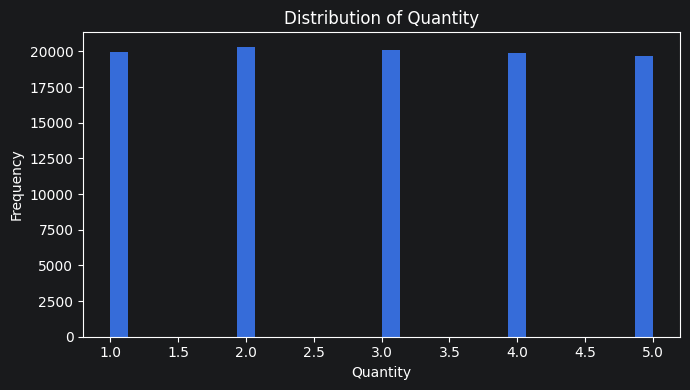

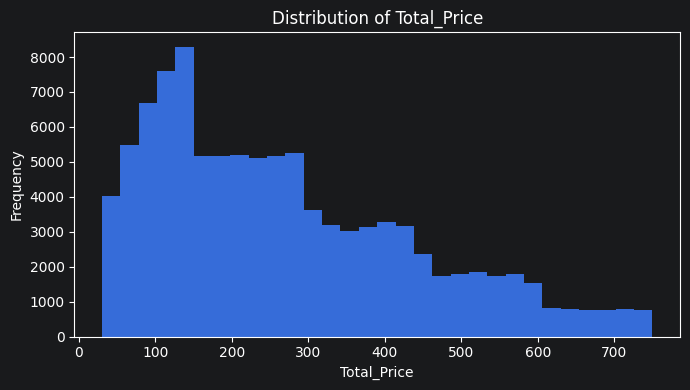

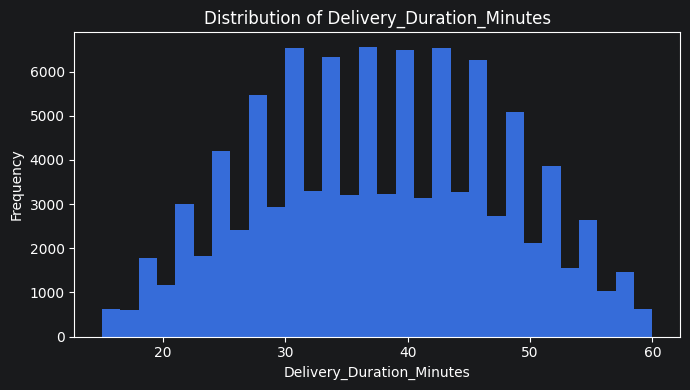

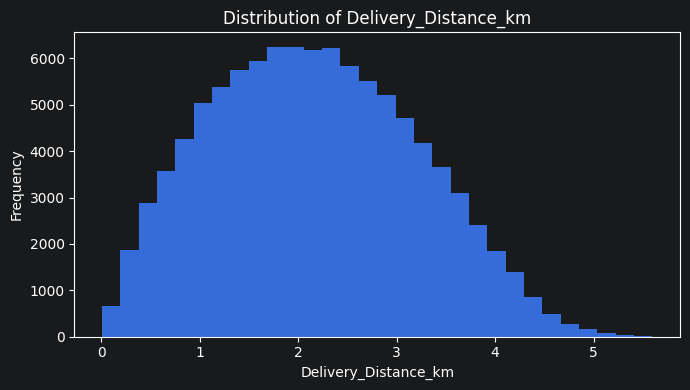

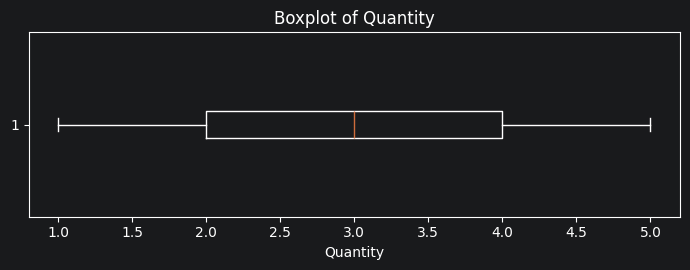

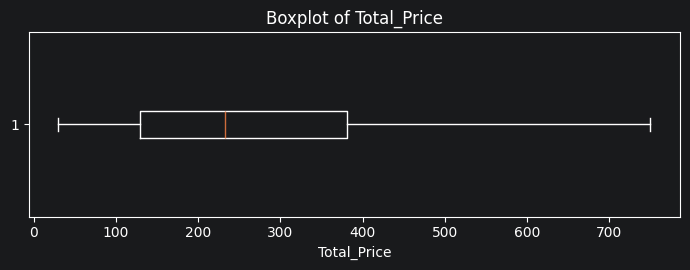

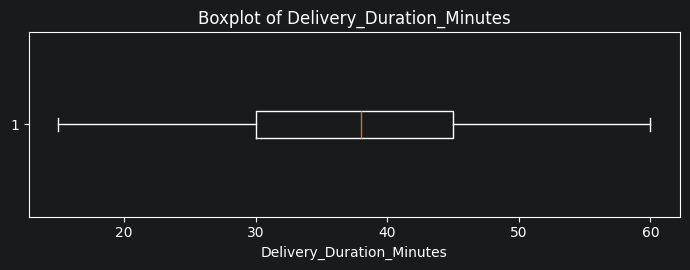

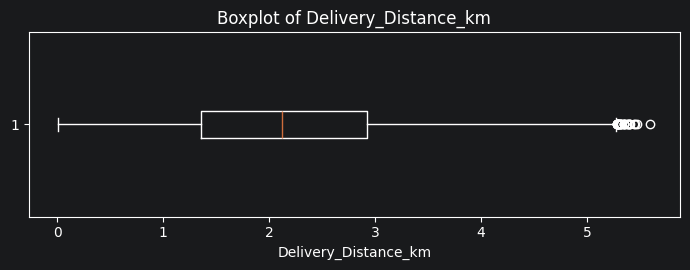

In [29]:
import matplotlib.pyplot as plt

# Histograms
for col in numerical_columns:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


# Boxplots
for col in numerical_columns:
    plt.figure(figsize=(7, 2.8))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


In [30]:
# Basic latitude / longitude validity check

latitude_columns = [
    "Restaurant_Lat",
    "Customer_Lat",
    "Driver_Lat"
]

longitude_columns = [
    "Restaurant_Lon",
    "Customer_Lon",
    "Driver_Lon"
]

geo_results = []

for col in latitude_columns:
    invalid = ((df[col] < -90) | (df[col] > 90)).sum()

    geo_results.append({
        "Column": col,
        "Valid Range": "-90 to 90",
        "Invalid Values": invalid
    })

for col in longitude_columns:
    invalid = ((df[col] < -180) | (df[col] > 180)).sum()

    geo_results.append({
        "Column": col,
        "Valid Range": "-180 to 180",
        "Invalid Values": invalid
    })

geo_results = pd.DataFrame(geo_results)

display(geo_results)

,Column,Valid Range,Invalid Values
0,Restaurant_Lat,-90 to 90,0
1,Customer_Lat,-90 to 90,0
2,Driver_Lat,-90 to 90,0
3,Restaurant_Lon,-180 to 180,0
4,Customer_Lon,-180 to 180,0
5,Driver_Lon,-180 to 180,0


In [31]:
# Show the unusual delivery-distance values, if any

distance_outliers = outlier_summary.loc[
    outlier_summary["Column"] == "Delivery_Distance_km"
]

display(distance_outliers)

,Column,Min,Median,Max,Lower IQR Bound,Upper IQR Bound,IQR Flagged,Flagged %
3,Delivery_Distance_km,0.008839,2.122694,5.597928,-0.997756,5.277892,30,0.029999


<div dir="rtl">

## Step 6 — Column Relationships & Dependencies

هنا بنراجع أهم العلاقات بين الـcolumns عشان نتأكد إن الـdata منطقية internally.

هنركز على:
- العلاقة بين الـOrder Time والـDelivery Time والـDelivery Duration.
- العلاقة بين الـRestaurant/Customer coordinates والـDelivery Distance.
- سلوك الـIDs والـrepeated entities.

الهدف هنا validation وفهم للـdata، مش Cleaning.

</div>

In [32]:
# Identifier behavior

id_columns = [
    "Order_ID",
    "User_ID",
    "Restaurant_ID",
    "Driver_ID"
]

id_summary = pd.DataFrame({
    "Column": id_columns,
    "Unique Values": [df[col].nunique() for col in id_columns],
    "Repeated Values": [
        df[col].duplicated().sum()
        for col in id_columns
    ]
})

display(id_summary)

,Column,Unique Values,Repeated Values
0,Order_ID,100002,0
1,User_ID,9000,91002
2,Restaurant_ID,1000,99002
3,Driver_ID,500,99502


In [33]:
# Parse timestamps

order_time = pd.to_datetime(
    df["Order_Time"],
    format="%d-%m-%Y %H:%M"
)

delivery_time = pd.to_datetime(
    df["Delivery_Time"],
    format="%d-%m-%Y %H:%M"
)

# Calculate duration from timestamps
calculated_duration = (
    delivery_time - order_time
).dt.total_seconds() / 60

duration_difference = (
    calculated_duration - df["Delivery_Duration_Minutes"]
).abs()

print(
    "Delivery_Time earlier than Order_Time:",
    (delivery_time < order_time).sum()
)

print(
    "Duration mismatches:",
    (duration_difference > 0.001).sum()
)

print(
    "Maximum duration difference:",
    duration_difference.max()
)

Delivery_Time earlier than Order_Time: 0
Duration mismatches: 0
Maximum duration difference: 0.0


In [34]:
import numpy as np

# Haversine distance between restaurant and customer
lat1 = np.radians(df["Restaurant_Lat"])
lon1 = np.radians(df["Restaurant_Lon"])
lat2 = np.radians(df["Customer_Lat"])
lon2 = np.radians(df["Customer_Lon"])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = (
    np.sin(dlat / 2) ** 2
    + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
)

earth_radius_km = 6371

calculated_distance = (
    2 * earth_radius_km * np.arcsin(np.sqrt(a))
)

distance_difference = (
    calculated_distance - df["Delivery_Distance_km"]
).abs()

print(
    "Rows with distance difference > 0.10 km:",
    (distance_difference > 0.10).sum()
)

print(
    "Mean absolute distance difference:",
    distance_difference.mean()
)

Rows with distance difference > 0.10 km: 2
Mean absolute distance difference: 0.003669694703745974


In [35]:
# Check delivery information across order statuses

status_summary = (
    df.groupby("Order_Status")
      .agg(
          Orders=("Order_ID", "count"),
          With_Delivery_Time=("Delivery_Time", "count"),
          With_Duration=("Delivery_Duration_Minutes", "count")
      )
)

display(status_summary)

,Orders,With_Delivery_Time,With_Duration
Order_Status,,,
Cancelled,9812,9812,9812
Delivered,85199,85199,85199
In Transit,4991,4991,4991


<div dir="rtl">

### Observation

الـ`Cancelled` والـ`In Transit` orders ما زال عندها `Delivery_Time` و`Delivery_Duration_Minutes`.

ده **مش بنعتبره data error حاليًا**، لأن الـCSV لوحده مش موضح business rule يحدد هل الـtimestamps دي متوقعة لكل status ولا لأ.

بالتالي هنسيبها زي ما هي، وأي decision عليها يتاخد في Phase 2 فقط لو احتجناه للتحليل.

</div>

Phase 1 — Data Understanding

1. Load Raw Dataset done 
   ↓
2. Column Understanding & Data Types done
   ↓
3. Missing Values & Duplicates done
   ↓
4. Unique Values & Value Inspection done
   ↓
5. Preliminary Outlier Analysis done
   ↓
6. Column Relationships & Dependencies done

<div dir="rtl">

# Step 7 — Data Understanding Findings & Cleaning Plan

في المرحلة دي بنسجل المشاكل التي تم اكتشافها والقرار الذي سيتم اتخاذه في مرحلة الـCleaning.

**مهم:** هذا القسم لا يطبق الـCleaning نفسه؛ هو documentation للقرارات.
</div>

In [36]:
# Compact data-quality findings summary

quality_summary = pd.DataFrame({
    "Check": [
        "Rows",
        "Columns",
        "Exact duplicate rows",
        "Total missing values",
        "Invalid numeric/range checks",
        "Invalid datetime values",
        "Delivery time before order time",
        "Duration mismatches",
        "Distance mismatches > 0.10 km"
    ],
    "Result": [
        len(df),
        df.shape[1],
        int(df.duplicated().sum()),
        int(df.isna().sum().sum()),
        int(sum(sanity_checks.values())),
        int(sum(
            pd.to_datetime(
                df[col],
                format="%d-%m-%Y %H:%M",
                errors="coerce"
            ).isna().sum()
            for col in ["Order_Time", "Delivery_Time"]
        )),
        int((delivery_time < order_time).sum()),
        int((duration_difference > 0.001).sum()),
        int((distance_difference > 0.10).sum())
    ]
})

display(quality_summary)


,Check,Result
0,Rows,100002
1,Columns,23
2,Exact duplicate rows,0
3,Total missing values,0
4,Invalid numeric/range checks,0
5,Invalid datetime values,0
6,Delivery time before order time,0
7,Duration mismatches,0
8,Distance mismatches > 0.10 km,2


<div dir="rtl">

## Cleaning Decision Log

| Issue | Decision | Reason |
|---|---|---|
| Exact duplicate rows | Drop only if found | Exact duplicates do not add information |
| Missing values | Investigate by column/status before imputation | Avoid inappropriate mean/mode filling |
| Whitespace | Trim in Cleaning phase if detected | Standardize text values |
| Categorical inconsistencies | Standardize only after reviewing observed values | Preserve valid categories |
| Invalid ranges | Investigate and correct/remove only when confirmed as errors | Do not confuse unusual values with errors |
| Outliers | Flag and investigate; do not automatically remove | Statistical outliers may be genuine observations |
| Datetime | Convert to proper datetime in Cleaning/Transformation | Required for reliable time analysis |
| Distance mismatch | Review the small number of mismatches | Avoid changing values without evidence |

</div>

<div dir="rtl">

# Step 8 — Final Validation Template

بعد تنفيذ الـCleaning في الـCleaning phase، أعد تشغيل هذه checks للتأكد من أن:
1. Row/column counts are reasonable.
2. Missing values are handled according to the documented decisions.
3. Exact duplicates are removed if any existed.
4. Data types match the intended logical types.
5. Categorical values are standardized.
6. Invalid ranges are resolved or documented.
7. Outlier decisions are documented.
8. A sample of the cleaned data is compared with the original raw data.
9. All transformations are recorded for reproducibility.

</div>

<div dir="rtl">

# Step 9 — Cleaning & Standardization

الـsections السابقة عملت inspection وvalidation على الـraw data.

من هنا نبدأ تطبيق الـCleaning على **نسخة** من الـraw DataFrame اسمها `df_clean`، ونحتفظ بـ`df` كمرجع للأصل.

كل transformation هنا موثق وقابل لإعادة التشغيل.
</div>

In [37]:
# Create a separate working copy
df_clean = df.copy()

# Keep the raw dataframe unchanged for comparison
raw_shape = df.shape
raw_duplicate_count = int(df_clean.duplicated().sum())

print("Raw shape:", raw_shape)
print("Exact duplicate rows before cleaning:", raw_duplicate_count)


Raw shape: (100002, 23)
Exact duplicate rows before cleaning: 0


### 9.1 Exact duplicates

حسب المطلوب: الـexact duplicate rows يتم حذفها.

تكرار IDs مثل `User_ID`, `Restaurant_ID`, أو `Driver_ID` وحده **ليس duplicate row**.


In [38]:
# Drop exact duplicate rows
before_rows = len(df_clean)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

after_rows = len(df_clean)

print("Rows before:", before_rows)
print("Rows after:", after_rows)
print("Exact duplicates removed:", before_rows - after_rows)


Rows before: 100002
Rows after: 100002
Exact duplicates removed: 0


### 9.2 Text standardization

نطبق:
- trimming للـleading/trailing whitespace
- توحيد case للـcategorical values
- standardization للقيم المعروفة

لا نغير `Item_Name` أو `City` إلى lowercase بالكامل لأنهما ممكن يظهران في التقارير بصيغة title case.


In [39]:
# Trim whitespace from text columns
text_columns = df_clean.select_dtypes(include=["object", "string"]).columns

for col in text_columns:
    df_clean[col] = df_clean[col].astype("string").str.strip()

# Standardize known categorical labels
category_maps = {
    "Payment_Method": {
        "cash": "Cash",
        "wallet": "Wallet",
        "credit card": "Credit Card",
        "credit_card": "Credit Card"
    },
    "Order_Status": {
        "delivered": "Delivered",
        "cancelled": "Cancelled",
        "canceled": "Cancelled",
        "in transit": "In Transit"
    },
    "Driver_Vehicle": {
        "bicycle": "Bicycle",
        "car": "Car",
        "motorbike": "Motorbike",
        "motorcycle": "Motorbike"
    },
    "Traffic_Level": {
        "low": "Low",
        "medium": "Medium",
        "high": "High"
    },
    "Driver_Availability": {
        "online": "Online",
        "offline": "Offline"
    }
}

for col, mapping in category_maps.items():
    normalized = df_clean[col].astype("string").str.strip().str.lower()
    df_clean[col] = normalized.map(mapping).fillna(df_clean[col])

print("Text trimming and categorical standardization completed.")


Text trimming and categorical standardization completed.


### 9.3 Missing-value handling

لا يتم افتراض طريقة واحدة لكل column.

الكود التالي:
- يحول disguised text placeholders إلى `NaN`
- يترك numeric `999/-999` بدون تغيير إلا إذا تم تأكيد أنها placeholders
- يطبق action map واضح وقابل للتعديل

**قبل تشغيل imputation، راجع `missing_decisions` الناتج في Step 3A.**


In [40]:
import numpy as np

# Convert confirmed text placeholders to NaN
for col in df_clean.select_dtypes(include=["object", "string"]).columns:
    normalized = df_clean[col].astype("string").str.strip().str.lower()
    mask = normalized.isin(missing_tokens)
    df_clean.loc[mask, col] = np.nan

# Explicit, documented actions.
# Leave columns out of this dictionary when the correct business decision is
# to investigate/flag rather than impute.
missing_action_map = {
    # Example:
    # "Some_Numeric_Column": "median",
    # "Some_Categorical_Column": "mode",
}

missing_transformation_log = []

for col, action in missing_action_map.items():
    if col not in df_clean.columns:
        continue

    missing_before = int(df_clean[col].isna().sum())

    if action == "median" and pd.api.types.is_numeric_dtype(df_clean[col]):
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    elif action == "mode":
        mode_values = df_clean[col].mode(dropna=True)
        if len(mode_values) > 0:
            df_clean[col] = df_clean[col].fillna(mode_values.iloc[0])

    missing_after = int(df_clean[col].isna().sum())

    missing_transformation_log.append({
        "Column": col,
        "Action": action,
        "Missing Before": missing_before,
        "Missing After": missing_after
    })

display(pd.DataFrame(missing_transformation_log))


""


### 9.4 Date formats and units

The dataset uses:
- `Order_Time` and `Delivery_Time` as timestamps
- `Delivery_Duration_Minutes` in minutes
- `Delivery_Distance_km` in kilometers
- `Total_Price` as the monetary amount

We convert timestamps to real datetime objects and retain the documented units.


In [41]:
# Standardize datetime columns
for col in ["Order_Time", "Delivery_Time"]:
    df_clean[col] = pd.to_datetime(
        df_clean[col],
        format="%d-%m-%Y %H:%M",
        errors="coerce"
    )

# Numeric conversion for measurement columns
numeric_measurement_columns = [
    "Quantity",
    "Total_Price",
    "Delivery_Duration_Minutes",
    "Delivery_Distance_km",
    "Restaurant_Lat",
    "Restaurant_Lon",
    "Customer_Lat",
    "Customer_Lon",
    "Driver_Lat",
    "Driver_Lon"
]

for col in numeric_measurement_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

print("Datetime and numeric types standardized.")
display(df_clean[["Order_Time", "Delivery_Time"]].dtypes)


Datetime and numeric types standardized.


Order_Time       datetime64[us]
Delivery_Time    datetime64[us]
dtype: object

### 9.5 Validity and allowed-value checks after standardization


In [42]:
# Allowed-value validation after standardization

allowed_validation = {}

for col, allowed in allowed_values.items():
    observed = set(
        df_clean[col].dropna().astype(str).str.strip().unique()
    )
    allowed_validation[col] = sorted(observed - allowed)

allowed_validation = pd.DataFrame([
    {
        "Column": col,
        "Unexpected Values": values,
        "Unexpected Count": len(values)
    }
    for col, values in allowed_validation.items()
])

display(allowed_validation)


# Numeric plausibility checks
range_validation = pd.DataFrame({
    "Check": [
        "Quantity <= 0",
        "Total_Price <= 0",
        "Delivery_Duration_Minutes <= 0",
        "Delivery_Distance_km < 0",
        "Invalid latitude",
        "Invalid longitude"
    ],
    "Count": [
        int((df_clean["Quantity"] <= 0).sum()),
        int((df_clean["Total_Price"] <= 0).sum()),
        int((df_clean["Delivery_Duration_Minutes"] <= 0).sum()),
        int((df_clean["Delivery_Distance_km"] < 0).sum()),
        int((
            (df_clean[["Restaurant_Lat","Customer_Lat","Driver_Lat"]] < -90) |
            (df_clean[["Restaurant_Lat","Customer_Lat","Driver_Lat"]] > 90)
        ).any(axis=1).sum()),
        int((
            (df_clean[["Restaurant_Lon","Customer_Lon","Driver_Lon"]] < -180) |
            (df_clean[["Restaurant_Lon","Customer_Lon","Driver_Lon"]] > 180)
        ).any(axis=1).sum())
    ]
})

display(range_validation)


,Column,Unexpected Values,Unexpected Count
0,Payment_Method,[],0
1,Order_Status,[],0
2,Driver_Vehicle,[],0
3,Traffic_Level,[],0
4,Driver_Availability,[],0


,Check,Count
0,Quantity <= 0,0
1,Total_Price <= 0,0
2,Delivery_Duration_Minutes <= 0,0
3,Delivery_Distance_km < 0,0
4,Invalid latitude,0
5,Invalid longitude,0


### 9.6 Structural checks

For this flat CSV:
- one row represents one order record
- columns represent variables
- IDs remain separate
- no split/merge is required unless inspection reveals a structural issue

The raw file is also checked for delimiter consistency.


In [43]:
# Lightweight structural / delimiter check on the raw CSV

from pathlib import Path
import csv

raw_path = Path("Order_delivery.csv")

if raw_path.exists():
    sample_lines = raw_path.read_text(
        encoding="utf-8-sig",
        errors="replace"
    ).splitlines()[:5]

    print("Raw file first 5 lines:")
    for line in sample_lines:
        print(line[:250])

    try:
        dialect = csv.Sniffer().sniff("\n".join(sample_lines))
        print("\nDetected delimiter:", repr(dialect.delimiter))
    except csv.Error:
        print("\nCould not confidently infer delimiter from the sample.")

print("\nCurrent structure:")
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))
print("Each row represents one order record.")


Raw file first 5 lines:
Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,D
1,U3522,358,485,Fried Chicken,3,273.72,16-06-2025 08:32,16-06-2025 09:11,39,Alexandria,Wallet,Delivered,Motorbike,31.1950816,29.92193116,31.19140352,29.90498216,31.21565812,29.9106644,1.666106279,High,Offline
2,U9214,316,65,Sandwich,3,365.82,03-06-2025 21:27,03-06-2025 22:00,33,Zagazig,Credit Card,Delivered,Motorbike,30.60572857,31.50307887,30.58604706,31.48582035,30.58032854,31.5023799,2.738697528,Low,Online
3,U7307,357,309,Koshary,3,401.94,01-06-2025 14:48,01-06-2025 15:26,38,Assiut,Cash,In Transit,Car,27.19017976,31.17774148,27.16486862,31.16921757,27.16297639,31.18945766,2.929078717,Medium,Online
4,U3612,420,32,Sushi,2,221.18,13-06-2025 02:30,13-06-2025 03:22,52,Mansoura,Cash,Delivered,Car,31.04184634,31.3812285

# Step 10 — Final Validation

بعد الـCleaning، نعيد نفس quality checks ونقارن الـcleaned data بالـraw data.

أي تغيير في row count أو missingness أو values لازم يكون قابل للتفسير من خلال الـtransformation log.


In [44]:
# Final validation summary

final_validation = pd.DataFrame({
    "Check": [
        "Raw rows",
        "Cleaned rows",
        "Raw columns",
        "Cleaned columns",
        "Exact duplicates remaining",
        "Total missing values remaining",
        "Invalid datetime values",
        "Rows with invalid latitude",
        "Rows with invalid longitude"
    ],
    "Result": [
        len(df),
        len(df_clean),
        df.shape[1],
        df_clean.shape[1],
        int(df_clean.duplicated().sum()),
        int(df_clean.isna().sum().sum()),
        int(df_clean[["Order_Time","Delivery_Time"]].isna().any(axis=1).sum()),
        int((
            (df_clean[["Restaurant_Lat","Customer_Lat","Driver_Lat"]] < -90) |
            (df_clean[["Restaurant_Lat","Customer_Lat","Driver_Lat"]] > 90)
        ).any(axis=1).sum()),
        int((
            (df_clean[["Restaurant_Lon","Customer_Lon","Driver_Lon"]] < -180) |
            (df_clean[["Restaurant_Lon","Customer_Lon","Driver_Lon"]] > 180)
        ).any(axis=1).sum())
    ]
})

display(final_validation)


# Re-check summary statistics
print("Cleaned descriptive statistics:")
display(df_clean.describe(include="all").T)


# Spot-check the same original indices where possible
sample_n = min(5, len(df))
sample_indices = df.sample(n=sample_n, random_state=42).index

comparison = pd.DataFrame({
    "Original Order_ID": df.loc[sample_indices, "Order_ID"].astype(str).values,
    "Cleaned Order_ID": df_clean["Order_ID"].astype(str).head(sample_n).values
})

display(comparison)


,Check,Result
0,Raw rows,100002
1,Cleaned rows,100002
2,Raw columns,23
3,Cleaned columns,23
4,Exact duplicates remaining,0
5,Total missing values remaining,0
6,Invalid datetime values,0
7,Rows with invalid latitude,0
8,Rows with invalid longitude,0


Cleaned descriptive statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Order_ID,100002.0,NaN,NaN,NaN,50001.5,1.0,25001.25,50001.5,75001.75,100002.0,28868.235147
User_ID,100002,9000,U1071,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Restaurant_ID,100002.0,NaN,NaN,NaN,499.832513,1.0,250.0,499.0,750.0,1000.0,288.253044
Driver_ID,100002.0,NaN,NaN,NaN,250.792414,1.0,126.0,251.0,376.0,500.0,144.288871
Item_Name,100002,9,Shawarma,11320,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,100002.0,NaN,NaN,NaN,2.9911,1.0,2.0,3.0,4.0,5.0,1.410121
Total_Price,100002.0,NaN,NaN,NaN,268.922678,30.0,129.43,233.2,381.5075,750.0,170.490102
Order_Time,100002,NaN,NaN,NaN,2025-06-08 21:57:53.907121,2025-06-01 10:00:00,2025-06-05 03:48:00,2025-06-08 21:46:00,2025-06-12 16:08:00,2025-06-16 10:00:00,NaN
Delivery_Time,100002,NaN,NaN,NaN,2025-06-08 22:35:25.119697,2025-06-01 10:23:00,2025-06-05 04:24:00,2025-06-08 22:22:00,2025-06-12 16:46:00,2025-06-16 10:52:00,NaN
Delivery_Duration_Minutes,100002.0,NaN,NaN,NaN,37.52021,15.0,30.0,38.0,45.0,60.0,10.06083


,Original Order_ID,Cleaned Order_ID
0,62005,1
1,58590,2
2,1957,3
3,11530,4
4,39496,5


## Transformation Log

Use this table as the reproducibility record for the final report:

| Transformation | Applied to | Reason |
|---|---|---|
| Exact duplicate removal | Full rows | Remove identical observations |
| Whitespace trimming | Text columns | Standardize labels |
| Categorical label mapping | Known categorical columns | Merge equivalent labels |
| Text placeholders → NaN | Text columns | Make missingness explicit |
| Datetime parsing | Order/Delivery timestamps | Correct logical type |
| Numeric conversion | Measurement columns | Ensure numerical operations are valid |
| Missing-value imputation | Only columns listed in `missing_action_map` | Documented, column-specific decision |
| Outlier handling | No automatic deletion | Outliers require investigation before removal |
| Range validation | Numeric/geographic columns | Enforce plausible constraints |
| Structural validation | Raw CSV + tabular structure | Ensure tidy one-observation-per-row structure |

**Important:** keep `df` unchanged as the raw reference and use `df_clean` for downstream analysis.
